In [2]:
import requests
from bs4 import BeautifulSoup

In [3]:
url = "https://quotes.toscrape.com"

response = requests.get(url)

print(response.status_code)

200


In [4]:
html_content = response.text

print(html_content[:500])

<!DOCTYPE html>
<html lang="en">
<head>
	<meta charset="UTF-8">
	<title>Quotes to Scrape</title>
    <link rel="stylesheet" href="/static/bootstrap.min.css">
    <link rel="stylesheet" href="/static/main.css">
    
    
</head>
<body>
    <div class="container">
        <div class="row header-box">
            <div class="col-md-8">
                <h1>
                    <a href="/" style="text-decoration: none">Quotes to Scrape</a>
                </h1>
            </div>
            <div cla


In [5]:
soup = BeautifulSoup(html_content, "html.parser")

In [9]:
quotes = soup.find_all("div", class_="quote")

print(len(quotes))

10


In [10]:
for quote in quotes:
    text = quote.find("span", class_="text").text
    print(text)

“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
“It is our choices, Harry, that show what we truly are, far more than our abilities.”
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
“Try not to become a man of success. Rather become a man of value.”
“It is better to be hated for what you are than to be loved for what you are not.”
“I have not failed. I've just found 10,000 ways that won't work.”
“A woman is like a tea bag; you never know how strong it is until it's in hot water.”
“A day without sunshine is like, you know, night.”


In [11]:
for quote in quotes:
    author = quote.find("small", class_="author").text
    print(author)

Albert Einstein
J.K. Rowling
Albert Einstein
Jane Austen
Marilyn Monroe
Albert Einstein
André Gide
Thomas A. Edison
Eleanor Roosevelt
Steve Martin


In [12]:
for quote in quotes:
    tags = quote.find_all("a", class_="tag")

    tag_list = [tag.text for tag in tags]

    print(tag_list)

['change', 'deep-thoughts', 'thinking', 'world']
['abilities', 'choices']
['inspirational', 'life', 'live', 'miracle', 'miracles']
['aliteracy', 'books', 'classic', 'humor']
['be-yourself', 'inspirational']
['adulthood', 'success', 'value']
['life', 'love']
['edison', 'failure', 'inspirational', 'paraphrased']
['misattributed-eleanor-roosevelt']
['humor', 'obvious', 'simile']


In [14]:
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

quotes = soup.find_all("div", class_="quote")

for quote in quotes:

    text = quote.find("span", class_="text").text

    author = quote.find("small", class_="author").text

    tags = quote.find_all("a", class_="tag")

    tag_list = [tag.text for tag in tags]

    print("Quote:", text)
    print("Author:", author)
    print("Tags:", tag_list)
    print("-" * 50)

Quote: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Author: Albert Einstein
Tags: ['change', 'deep-thoughts', 'thinking', 'world']
--------------------------------------------------
Quote: “It is our choices, Harry, that show what we truly are, far more than our abilities.”
Author: J.K. Rowling
Tags: ['abilities', 'choices']
--------------------------------------------------
Quote: “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
Author: Albert Einstein
Tags: ['inspirational', 'life', 'live', 'miracle', 'miracles']
--------------------------------------------------
Quote: “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
Author: Jane Austen
Tags: ['aliteracy', 'books', 'classic', 'humor']
--------------------------------------------------
Quote: “Imperfection is beauty, madness is

In [15]:
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

quotes = soup.find_all("div", class_="quote")

for quote in quotes:

    text = quote.find("span", class_="text").text

    author = quote.find("small", class_="author").text

    tags = quote.find_all("a", class_="tag")

    tag_list = [tag.text for tag in tags]

    print("Quote:", text)
    print("Author:", author)
    print("Tags:", tag_list)
    print("-" * 50)

Quote: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Author: Albert Einstein
Tags: ['change', 'deep-thoughts', 'thinking', 'world']
--------------------------------------------------
Quote: “It is our choices, Harry, that show what we truly are, far more than our abilities.”
Author: J.K. Rowling
Tags: ['abilities', 'choices']
--------------------------------------------------
Quote: “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
Author: Albert Einstein
Tags: ['inspirational', 'life', 'live', 'miracle', 'miracles']
--------------------------------------------------
Quote: “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
Author: Jane Austen
Tags: ['aliteracy', 'books', 'classic', 'humor']
--------------------------------------------------
Quote: “Imperfection is beauty, madness is

In [16]:
import pandas as pd

data = []

for quote in quotes:

    text = quote.find("span", class_="text").text

    author = quote.find("small", class_="author").text

    tags = quote.find_all("a", class_="tag")

    tag_list = [tag.text for tag in tags]

    data.append([text, author, ", ".join(tag_list)])

df = pd.DataFrame(data, columns=["Quote", "Author", "Tags"])

print(df.head())

                                               Quote           Author  \
0  “The world as we have created it is a process ...  Albert Einstein   
1  “It is our choices, Harry, that show what we t...     J.K. Rowling   
2  “There are only two ways to live your life. On...  Albert Einstein   
3  “The person, be it gentleman or lady, who has ...      Jane Austen   
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe   

                                           Tags  
0        change, deep-thoughts, thinking, world  
1                            abilities, choices  
2  inspirational, life, live, miracle, miracles  
3              aliteracy, books, classic, humor  
4                    be-yourself, inspirational  


In [17]:
df.to_csv("quotes.csv", index=False)

print("CSV Saved Successfully")

CSV Saved Successfully


In [18]:
import matplotlib.pyplot as plt


In [19]:
v=pd.read_csv("quotes.csv")

In [22]:
v.head()

,Quote,Author,Tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"


In [23]:
v.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Quote   10 non-null     object
 1   Author  10 non-null     object
 2   Tags    10 non-null     object
dtypes: object(3)
memory usage: 372.0+ bytes


<Axes: xlabel='Author'>

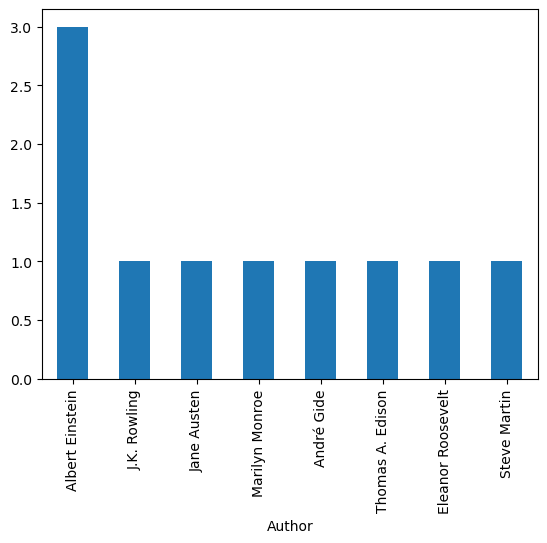

In [24]:
v['Author'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

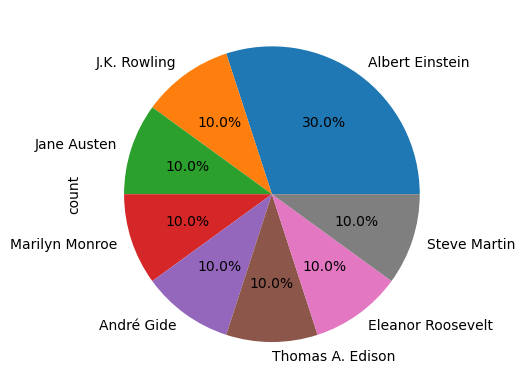

In [26]:
v['Author'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Author'>

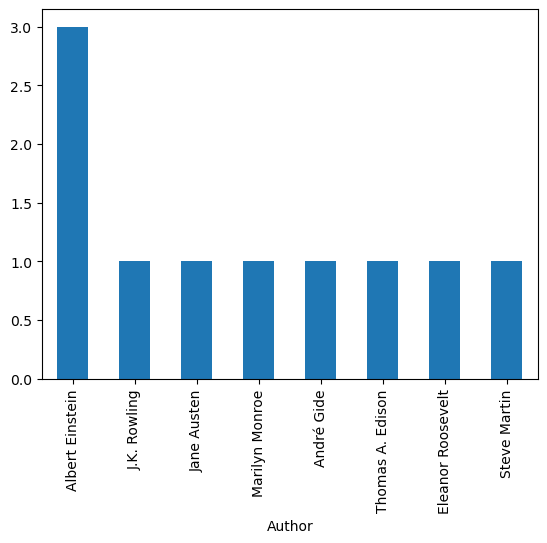

In [29]:
import seaborn as sns

v['Author'].value_counts().plot(kind='bar')